In [1]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/NLP_Project/cleaned_A_MASA.csv')

print(f"Data Loaded Successfully! Shape: {df.shape}")
display(df.head(2))

Mounted at /content/drive
Data Loaded Successfully! Shape: (6074, 7)


,domain_name,unified_sentiment,Sentences_clean,Aspects_clean,Aspects_sentiments_list,Aspects_list,length
0,Attractions,1.0,نصحوني بتجربه حمام الكبريت يمكنكم الدخول مع مج...,الحمام، العاملات، الانجليزيه,"[1, 1, -1]","['الحمام', 'العاملات', 'الانجليزيه']",43
1,Attractions,1.0,قلعه ساحره منظر خلاب للمدينه من اعلي القلعه يو...,قلعه، منظر، حديقه نباتات، مجري مائي,"[1, 1, 1, 1]","['قلعه', 'منظر', 'حديقه نباتات', 'مجري مائي']",22


**FastText Word Embeddings**

In [2]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ar.300.vec.gz
!gzip -d cc.ar.300.vec.gz

print("FastText Arabic Embeddings Downloaded and Extracted!")

--2026-05-13 18:35:39--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ar.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.68, 3.171.22.13, 3.171.22.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1272365870 (1.2G) [binary/octet-stream]
Saving to: ‘cc.ar.300.vec.gz’

cc.ar.300.vec.gz    100%[===================>]   1.18G  37.7MB/s    in 34s     

2026-05-13 18:36:13 (36.1 MB/s) - ‘cc.ar.300.vec.gz’ saved [1272365870/1272365870]

FastText Arabic Embeddings Downloaded and Extracted!


**Tokenization & Padding**

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

texts = df['Sentences_clean'].astype(str).values
labels = df['unified_sentiment'].values
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 128

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train_pad: (4859, 128)
Shape of X_test_pad: (1215, 128)
Shape of y_train: (4859,)


**FastText (Embedding Matrix)**

In [4]:
import numpy as np

embeddings_index = {}
print("Loading FastText word vectors... This might take a minute.")
with open('cc.ar.300.vec', 'r', encoding='utf-8', newline='\n', errors='ignore') as f:
    for line in f:
        values = line.rstrip().rsplit(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors in FastText.")

EMBEDDING_DIM = 300
word_index = tokenizer.word_index
num_words = min(MAX_VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

hits = 0
misses = 0

for word, i in word_index.items():
    if i >= MAX_VOCAB_SIZE:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print(f"Converted {hits} words ({hits/(hits+misses)*100:.2f}%)")
print(f"Missed {misses} words (Out of Vocabulary)")

Loading FastText word vectors... This might take a minute.
Found 2000000 word vectors in FastText.
Converted 18243 words (91.22%)
Missed 1756 words (Out of Vocabulary)


**Architecture BiLSTM**

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights calculated:", class_weights_dict)

model = Sequential([
    Embedding(input_dim=num_words,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_SEQUENCE_LENGTH,
              trainable=False),

    SpatialDropout1D(0.2),

    Bidirectional(LSTM(128, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\nModel Summary:")
print(model.summary())

Class Weights calculated: {0: np.float64(2.821718931475029), 1: np.float64(4.983589743589744), 2: np.float64(0.409006734006734)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

None


In [6]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting Training...")
history = model.fit(X_train_pad, y_train,
                    epochs=15,
                    batch_size=32,
                    validation_data=(X_test_pad, y_test),
                    class_weight=class_weights_dict,
                    callbacks=[early_stop])

Starting Training...
Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 97s 603ms/step - accuracy: 0.5956 - loss: 1.0294 - val_accuracy: 0.8379 - val_loss: 0.8146
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 92s 604ms/step - accuracy: 0.6746 - loss: 0.9344 - val_accuracy: 0.7374 - val_loss: 0.6941
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 152s 667ms/step - accuracy: 0.6934 - loss: 0.8486 - val_accuracy: 0.7136 - val_loss: 0.7640
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 91s 598ms/step - accuracy: 0.7154 - loss: 0.7901 - val_accuracy: 0.6387 - val_loss: 0.8223
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 142s 595ms/step - accuracy: 0.7174 - loss: 0.7517 - val_accuracy: 0.7539 - val_loss: 0.6342
Epoch 6/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 139s 578ms/step - accuracy: 0.7382 - loss: 0.6946 - val_accuracy: 0.7498 - val_loss: 0.6263
Epoch 7/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 153s 657ms/step - accuracy: 0.7627 - loss: 0.6321 - val_accuracy: 0.6601 - val_loss: 0.7769
Epoch 8/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 135s 611ms/step - 

38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.7498 - loss: 0.6263

Final Test Accuracy: 74.98%

38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step
--- Classification Report ---
              precision    recall  f1-score   support

        -1.0       0.51      0.67      0.58       144
         0.0       0.19      0.48      0.27        81
         1.0       0.95      0.78      0.86       990

    accuracy                           0.75      1215
   macro avg       0.55      0.65      0.57      1215
weighted avg       0.85      0.75      0.79      1215



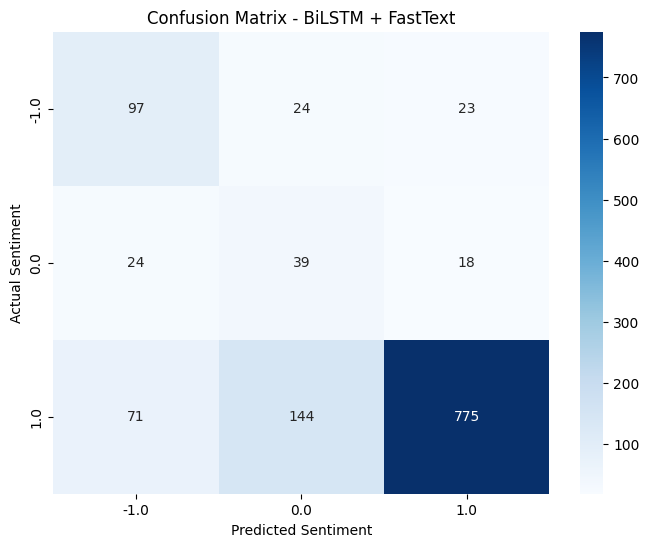

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

loss, accuracy = model.evaluate(X_test_pad, y_test)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%\n")
y_pred_probs = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

target_names = [str(cls) for cls in encoder.classes_]
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_classes, target_names=target_names))

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - BiLSTM + FastText')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()